In [1]:
!pip install /kaggle/input/fairlearn/fairlearn-*.whl


Processing /kaggle/input/fairlearn/fairlearn-0.13.0-py3-none-any.whl


In [2]:
!pip install /kaggle/input/pymoo-linux2/pymoo-0.6.1.6-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl


Processing /kaggle/input/pymoo-linux2/pymoo-0.6.1.6-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl
INFO: pip is looking at multiple versions of pymoo to determine which version is compatible with other requirements. This could take a while.
ERROR: Could not find a version that satisfies the requirement moocore>=0.1.7 (from pymoo) (from versions: none)
ERROR: No matching distribution found for moocore>=0.1.7


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/adult-census-income/adult.csv
/kaggle/input/compass/cox-violent-parsed.csv
/kaggle/input/compass/cox-violent-parsed_filt.csv
/kaggle/input/compass/compas-scores-raw.csv
/kaggle/input/compass/propublicaCompassRecividism_data_fairml.csv/._propublica_data_for_fairml.csv
/kaggle/input/compass/propublicaCompassRecividism_data_fairml.csv/propublica_data_for_fairml.csv


In [21]:
df = pd.read_csv("/kaggle/input/adult-census-income/adult.csv")


In [22]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values per column:\n", df.isna().sum())
print("\nUnique values in target:", df['income'].unique())

Shape: (32561, 15)

Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']

Missing values per column:
 age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Unique values in target: ['<=50K' '>50K']



Descriptive statistics:
                 age        fnlwgt  education.num  capital.gain  capital.loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours.per.week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


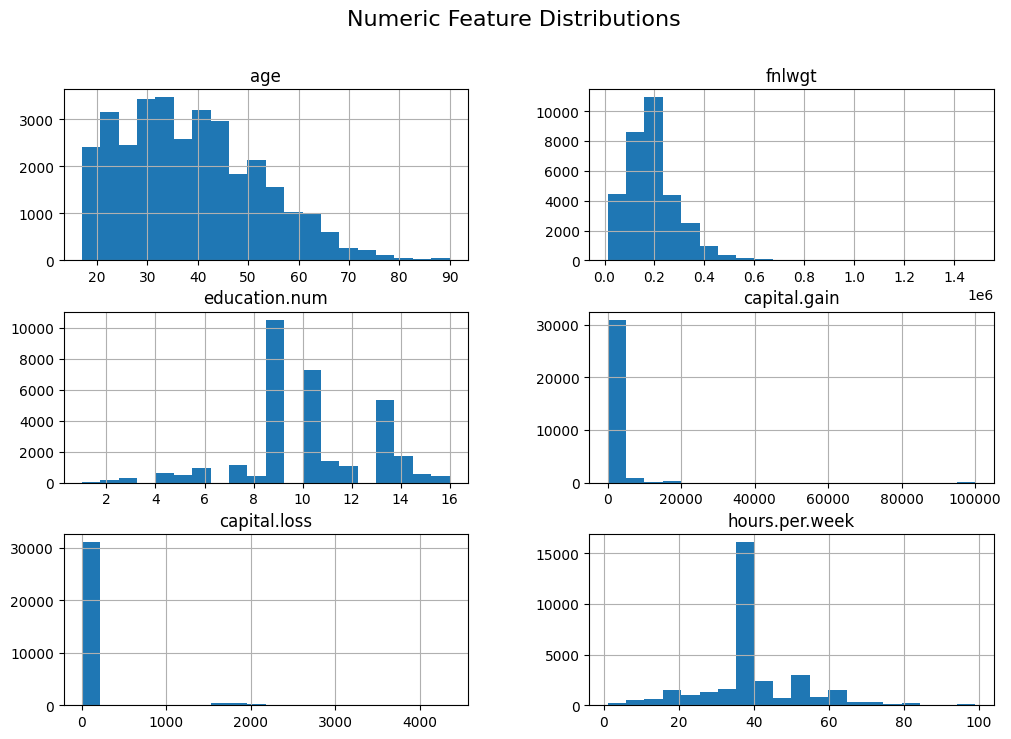

In [23]:
# Summary statistics
print("\nDescriptive statistics:\n", df.describe())

# Visualize numeric distributions
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.show()


In [24]:

# Check skewness
print("\nSkewness of numeric columns:")
print(df[num_cols].skew())



Skewness of numeric columns:
age                0.558743
fnlwgt             1.446980
education.num     -0.311676
capital.gain      11.953848
capital.loss       4.594629
hours.per.week     0.227643
dtype: float64


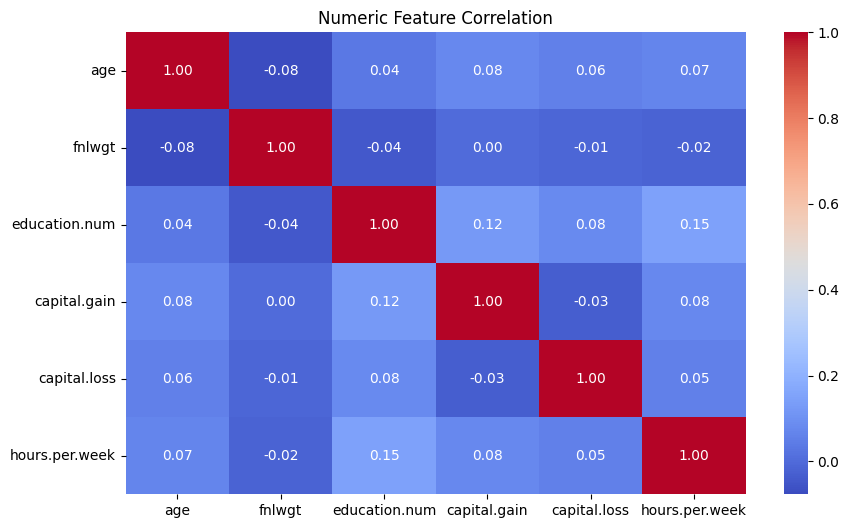

In [25]:

# Visualize correlation
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numeric Feature Correlation")
plt.show()

In [26]:

# Replace "?" with NaN (since the dataset uses "?" for missing values)
df = df.replace("?", np.nan)


In [27]:

# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns


# Numerical Imputation
# Use mean only if not skewed; otherwise mode
for col in num_cols:
    skewness = df[col].skew()
    if abs(skewness) > 1:
        # Highly skewed → use mode
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        # Fairly normal → use mean
        df[col] = df[col].fillna(df[col].mean())


In [28]:

# Categorical Imputation
# Use most frequent (mode) value
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])



In [29]:

label_enc = LabelEncoder()

# Encode binary categorical features and the target
binary_features = [col for col in cat_cols if df[col].nunique() == 2]
for col in binary_features:
    df[col] = label_enc.fit_transform(df[col])

# Encode target
df['income'] = label_enc.fit_transform(df['income'])

print("\nBinary encoded columns:", binary_features)
print("\nEncoded target unique values:", df['income'].unique())



Binary encoded columns: ['sex', 'income']

Encoded target unique values: [0 1]


In [30]:
# Split into features and target
X = df.drop('income', axis=1)
y = df['income']

# Train (70%), Validation (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTrain shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

# Check target balance
print("\nTarget distribution in splits:")
for name, arr in zip(['Train', 'Validation', 'Test'], [y_train, y_val, y_test]):
    print(f"{name} positive ratio: {arr.mean():.3f}")


Train shape: (22792, 14)
Validation shape: (4884, 14)
Test shape: (4885, 14)

Target distribution in splits:
Train positive ratio: 0.241
Validation positive ratio: 0.241
Test positive ratio: 0.241


Since implementing a full distributed control server is complex, we will simulate the "Interactive Training" loop by having the training process periodically check a shared configuration state (a simple dictionary or class instance) that an external agent (simulated by a separate function) can modify.

Task: Demonstrate how the training loop can dynamically change the learning rate based on a simulated external instruction.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- 1. Define the Control Mechanism (Simulated Control Server) ---
class ControlServer:
    """Simulates the shared state/control mechanism."""
    def __init__(self, initial_lr=0.01):
        self.learning_rate = initial_lr
        self.intervention_flag = False

    def get_lr(self):
        return self.learning_rate

    def set_lr(self, new_lr):
        """Action taken by the 'Expert' or automated agent."""
        print(f"\n--- INTERVENTION: Learning rate updated from {self.learning_rate:.4f} to {new_lr:.4f} ---")
        self.learning_rate = new_lr
        self.intervention_flag = True

    def reset_flag(self):
        self.intervention_flag = False

# --- 2. The Interactive Training Loop ---
def interactive_train_model(model, data_loader, control_server, num_epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=control_server.get_lr())

    for epoch in range(1, num_epochs + 1):
        # Dynamically update optimizer if intervention occurred
        if control_server.intervention_flag:
            for param_group in optimizer.param_groups:
                param_group['lr'] = control_server.get_lr()
            control_server.reset_flag()

        running_loss = 0.0
        for i, (inputs, labels) in enumerate(data_loader):
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(data_loader)
        print(f"Epoch {epoch}/{num_epochs}, Avg Loss: {avg_loss:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.4f}")

        # --- 3. Simulate External Feedback/Intervention Agent ---
        if epoch == 4:
            # Expert/Agent observes high loss/instability and decides to intervene
            control_server.set_lr(0.001) # Decrease LR
        elif epoch == 7:
            # Expert/Agent observes stability and decides to accelerate
            control_server.set_lr(0.005) # Increase LR


3. MOO in fairness and Bias paper

In [1]:
import numpy as np
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import StandardDataset
from sklearn.linear_model import LogisticRegression
from aif360.algorithms.inprocessing import AdversarialDebiasing

def load_adult_data():
    data = {
        'features': np.random.rand(100, 5),
        'labels': np.random.randint(0, 2, 100),
        'sex': np.random.randint(0, 2, 100)
    }

    dataset = StandardDataset(
        df=None,
        label_names=['income'],
        protected_attribute_names=['sex'],
        privileged_classes=[[1]],
        favorable_label=1
    )
    return dataset

def train_fair_model(dataset):
    unprivileged_groups = [{'sex': 0}]
    privileged_groups = [{'sex': 1}]

    debiaser = AdversarialDebiasing(
        privileged_groups=privileged_groups,
        unprivileged_groups=unprivileged_groups,
        scope_name="debiasing_model"
    )

    return debiaser

def evaluate_model(dataset_orig, dataset_pred, privileged_groups, unprivileged_groups):
    metric = BinaryLabelDatasetMetric(
        dataset_pred,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups
    )

    disparate_impact = metric.disparate_impact()
    mean_difference = metric.statistical_parity_difference()

    print(f"Statistical Parity Difference (Fairness): {mean_difference:.4f}")


ModuleNotFoundError: No module named 'aif360'

In [2]:
!git clone ehttps://github.com/yuntian-group/interactive-training.git

Cloning into 'interactive-training'...
git: 'remote-ehttps' is not a git command. See 'git --help'.

The most similar command is
	remote-https
